In [46]:
#inisialisasi library tambahan
!pip install scikit-fuzzy

In [47]:
#Gunakan dataset Mall Customers
import pandas as pd
url = "https://raw.githubusercontent.com/febbisena/DataMining/main/mall_customers.csv"
df = pd.read_csv(url)
df.head()

,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [48]:
#melakukan prepocessing
from sklearn.preprocessing import StandardScaler
X = df.iloc[:, 3:].values # Ambil fitur Annual Income dan Spending Score
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [49]:
#implementasi FCM
import numpy as np
import skfuzzy as fuzz
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(X_scaled.T, c=5, m=2.5, error=0.01, maxiter=1000, init=None)
df['Cluster'] = np.argmax(u, axis=0) + 1

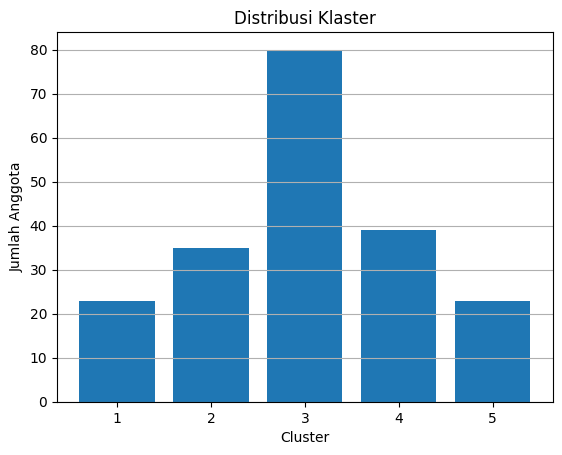

In [50]:
#visualisasi dan analisis klaster
#melakukan distribusi anggota setiap klaster
import matplotlib.pyplot as plt
cluster_counts = df['Cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel('Cluster')
plt.ylabel('Jumlah Anggota')
plt.title('Distribusi Klaster')
plt.grid(axis='y')
plt.show()

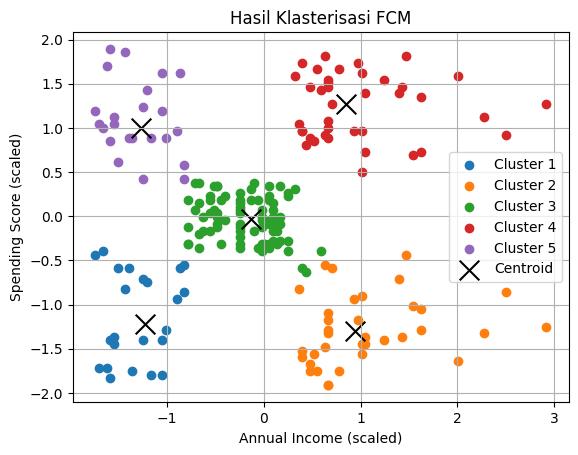

In [51]:
for i in range(5):
    plt.scatter(X_scaled[df['Cluster'] == i+1, 0], X_scaled[df['Cluster'] == i+1, 1], label=f'Cluster {i+1}')
plt.scatter(cntr[:, 0], cntr[:, 1], c='black', marker='x', s=200, label='Centroid')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('Hasil Klasterisasi FCM')
plt.legend()
plt.grid(True)

plt.show()

In [52]:
#eksperimen
#visualisasi derajat keanggotaan
pd.DataFrame(u.T[:10], columns=[f"Cluster {i+1}" for i in range(u.shape[0])])

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
0,0.412052,0.095121,0.192092,0.083551,0.217184
1,0.083411,0.049353,0.108847,0.078152,0.680237
2,0.616353,0.101603,0.123601,0.060834,0.097609
3,0.077326,0.043956,0.100252,0.067264,0.711202
4,0.401422,0.094598,0.198821,0.083783,0.221376
5,0.071889,0.040622,0.094265,0.061990,0.731234
6,0.634390,0.098219,0.118511,0.057566,0.091313
7,0.098529,0.066777,0.138266,0.121751,0.574677
8,0.606174,0.109533,0.126255,0.062242,0.095796
9,0.070142,0.038103,0.092819,0.056215,0.742721


In [53]:
#bandingkan dengan k-means
from sklearn.cluster import KMeans
km = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = km.fit_predict(X_scaled) + 1
df[['Cluster', 'KMeans_Cluster']].head(10)

,Cluster,KMeans_Cluster
0,1,5
1,5,3
2,1,5
3,5,3
4,1,5
5,5,3
6,1,5
7,5,3
8,1,5
9,5,3


In [54]:
#evaluasi silhouette score
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, np.argmax(u, axis=0))
print("Silhouette Score:", score)

Silhouette Score: 0.5518984396705728
